<a href="https://colab.research.google.com/github/sauravk21/cv_tutorial/blob/main/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## Code a NN from scratch
import numpy as np
from numpy.random import randn

N, D_in, H, D_out = 64, 1000, 100, 10
x, y = np.random.randn(N,D_in), np.random.randn(N,D_out)
w1, w2 = np.random.randn(D_in,H), np.random.randn(H,D_out)


for t in range(2000):
  h = 1/ (1+np.exp(-x.dot(w1)))
  y_pred = h.dot(w2)
  loss = np.square(y_pred - y).sum()

  grad_y_pred = 2.0*(y_pred - y)
  grad_w2 = h.T.dot(grad_y_pred)
  grad_h = grad_y_pred.dot(w2.T)
  grad_w1 = x.T.dot(grad_h * h * (1-h))

  w1-= 1e-4 * grad_w1
  w2-= 1e-4 * grad_w2



In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root = "data",
    train="True",
    download="True",
    transform = ToTensor()
)

test_data = datasets.FashionMNIST(
    root = "data",
    train="False",
    download="True",
    transform = ToTensor()
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 343kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.34MB/s]


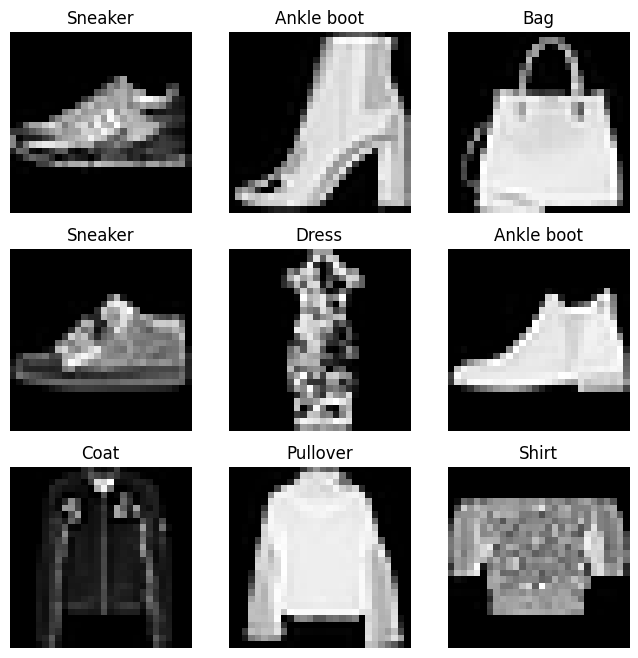

In [4]:
import random

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

figure = plt.figure(figsize=(8,8))

cols, rows = 3, 3
for i in range(1,cols*rows+1):
  sample_idx = random.randint(0, len(training_data) - 1)
  img, label = training_data[sample_idx]
  figure.add_subplot(rows,cols,i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(),cmap="gray")
plt.show()

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)


In [6]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork,self).__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,512),
        nn.ReLU(),
        nn.Linear(512,512),
        nn.ReLU(),
        nn.Linear(512,10),
        nn.ReLU()
    )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
    (5): ReLU()
  )
)


In [8]:
X = torch.rand(1,28,28,device = device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([2])


In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)

def train_loop(dataloader,model,loss_fn,optimizer):
  size = len(dataloader.dataset)
  for batch,(X,y) in enumerate(dataloader):
    pred = model(X)
    loss = loss_fn(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch%100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

In [10]:
def test_loop(dataloader,model,loss_fn):
  size = len(dataloader.dataset)
  test_loss, correct = 0 , 0

  with torch.no_grad():
    for X,y in dataloader:
      pred = model(X)
      test_loss += loss_fn(pred,y).item()
      correct+= (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss/=size
  correct/=size
  print(f"Test Error: \n Accuracy: {(100*correct) :>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [11]:
epochs = 10
for t in range(epochs):
  print(f"Epoch {t+1}\n--------------")
  train_loop(train_dataloader,model,loss_fn,optimizer)
  test_loop(test_dataloader,model,loss_fn)

print("Completed")

Epoch 1
--------------
loss: 2.297056 [    0/60000]
loss: 2.287699 [ 6400/60000]
loss: 2.286365 [12800/60000]
loss: 2.273893 [19200/60000]
loss: 2.263142 [25600/60000]
loss: 2.254534 [32000/60000]
loss: 2.258515 [38400/60000]
loss: 2.250254 [44800/60000]
loss: 2.251596 [51200/60000]
loss: 2.220145 [57600/60000]
Test Error: 
 Accuracy: 31.8%, Avg loss: 0.034919 

Epoch 2
--------------
loss: 2.247370 [    0/60000]
loss: 2.250223 [ 6400/60000]
loss: 2.239406 [12800/60000]
loss: 2.202052 [19200/60000]
loss: 2.209794 [25600/60000]
loss: 2.159558 [32000/60000]
loss: 2.196718 [38400/60000]
loss: 2.180429 [44800/60000]
loss: 2.168873 [51200/60000]
loss: 2.197783 [57600/60000]
Test Error: 
 Accuracy: 36.3%, Avg loss: 0.033587 

Epoch 3
--------------
loss: 2.151347 [    0/60000]
loss: 2.134824 [ 6400/60000]
loss: 2.065421 [12800/60000]
loss: 2.059097 [19200/60000]
loss: 2.070308 [25600/60000]
loss: 2.037948 [32000/60000]
loss: 2.098185 [38400/60000]
loss: 2.057064 [44800/60000]
loss: 1.972929 